# Informal results script for experimental results mid-development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

import os
import sys

sys.path.append(os.path.join(os.path.dirname(nb_name), '..'))

<IPython.core.display.Javascript object>

In [2]:
from plotting_functions import create_pearsons_violin

# Pre-modification results to identify gene subset to target

In [14]:
DATA_ROOT = '../data'
results = pd.read_csv(f'{DATA_ROOT}/Pearsons_results.csv', index_col = 0, header = 0)

In [15]:
negative_correlations = results[results['train_loss'] > 1]
negative_correlations['train_pearsons'] = 1 - negative_correlations['train_loss']
negative_correlations['test_pearsons'] = 1 - negative_correlations['test_loss']

In [19]:
negative_correlations_to_plot = negative_correlations[['train_pearsons', 'test_pearsons']]
negative_correlations_to_plot.columns = ['Train', 'Test']
negative_correlations_to_plot = negative_correlations_to_plot.melt()
negative_correlations_to_plot.columns = ['dataset', 'pearsons']
negative_correlations_to_plot.dataset.value_counts()

dataset
Train    894
Test     894
Name: count, dtype: int64

In [38]:
negative_correlations[['train_pearsons', 'test_pearsons']]['test_pearsons'].describe()

count    894.000000
mean      -0.225522
std        0.197513
min       -0.850348
25%       -0.320117
50%       -0.173309
75%       -0.070931
max        0.056655
Name: test_pearsons, dtype: float64

In [37]:
negative_correlations[['train_pearsons', 'test_pearsons']].melt()['value'].describe()

count    1788.000000
mean       -0.226162
std         0.196050
min        -0.853279
25%        -0.318148
50%        -0.172859
75%        -0.073611
max         0.056655
Name: value, dtype: float64

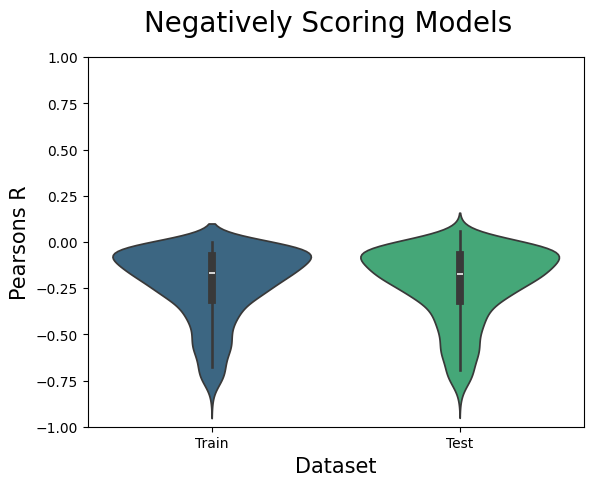

In [46]:
create_pearsons_violin(negative_correlations_to_plot, y_col = 'pearsons', title = 'Negatively Scoring Models', figure_root = './figures/experimental_figures/', file_title = 'negative_scoring_violins')

# Post-modification results to asssess change impacts

In [20]:
exp_results = pd.read_csv('../model_building/data/EXPERIMENTAL_results.csv', index_col = 0)

In [21]:
exp_results['train_pearsons'] = 1 - exp_results['train_loss']
exp_results['test_pearsons'] = 1 - exp_results['test_loss']

In [22]:
exp_results

,train_loss,test_loss,stopped_early,in_features,train_pearsons,test_pearsons
AARD,0.215048,0.213470,1,1197,0.784952,0.786530
ABCA12,0.463416,0.440934,1,1197,0.536584,0.559066
ABCA13,0.223228,0.256111,1,1197,0.776772,0.743889
ABRA,0.371654,0.356582,1,1197,0.628346,0.643418
ACMSD,0.123708,0.122007,1,1197,0.876292,0.877993
...,...,...,...,...,...,...
ZNHIT3,0.227330,0.231742,1,1197,0.772670,0.768258
ZNHIT6,0.170023,0.169689,1,1197,0.829977,0.830311
ZPBP,0.434948,0.420166,1,1197,0.565052,0.579834
ZSWIM2,0.438488,0.409172,1,1197,0.561512,0.590828


In [23]:
#transfrom dataframe to work with create_pearsons_violin
to_plot_df = exp_results[['train_pearsons', 'test_pearsons']]
to_plot_df.columns = ['Train', 'Test']
to_plot_df = to_plot_df.melt()
to_plot_df.columns = ['dataset', 'pearsons']

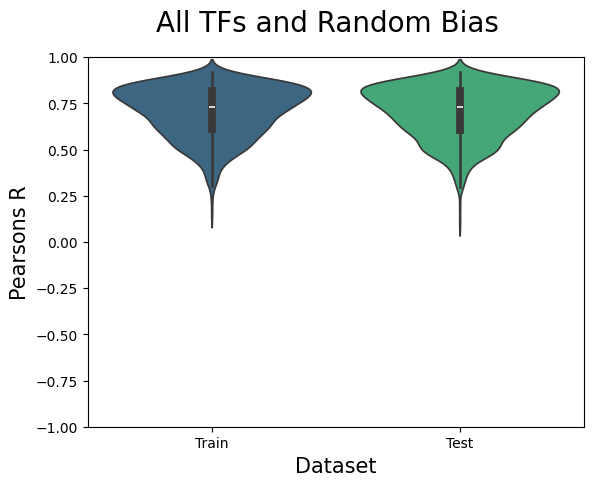

In [25]:
create_pearsons_violin(to_plot_df, y_col = 'pearsons', title = 'All TFs and Random Bias', figure_root = './figures/experimental_figures/', file_title = 'all_TFS_and_randn_bias', ylim = (-1, 1))

In [13]:
exp_results['train_pearsons'].describe()

count    894.000000
mean       0.087790
std        0.291157
min       -0.891292
25%       -0.073025
50%        0.081668
75%        0.280564
max        0.993994
Name: train_pearsons, dtype: float64

<Axes: ylabel='train_pearsons'>

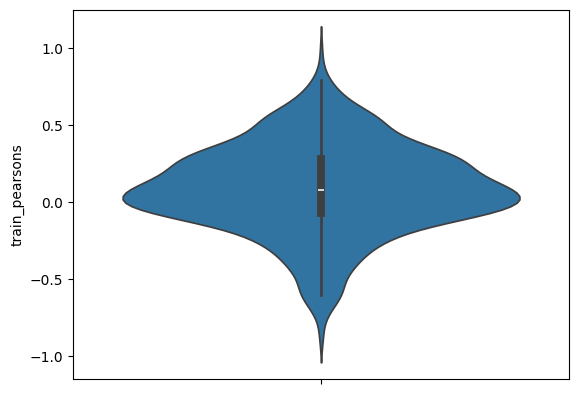

In [14]:
sns.violinplot(exp_results['train_pearsons'])